# NYC Airbnb 2026 Fair Price Estimation

Objective: build regression models that estimate a reasonable nightly Airbnb price in New York City from listing characteristics, then compare the observed listing price against that estimate to identify whether a listing appears overpriced or like a good deal. The analysis uses the 2026 market dataset at `data/airbnb_2026_market.csv`, which combines the January and February listings.

# Background
I had done a project for AMS 317 (Linear Regression Analysis) where my group and I looked into 2019 AirBnb dataset for New York City. We had done a complete data analysis, EDA, used ANOVA to measure the question "Does different types of rooms vs the number of reviews".

I wanted to do a similar analysis on the Airbnb dataset but I want to engineer some data myself this time rather than with Kaggle. Instead of just conducting an analysis and ANOVA. I wanted to build a model and maybe answer some business question. I am also a frequent Airbnb user when I go on trips and lots of times, I found myself asking, "Is this price reasonable in comparision to the surrounding Airbnb based on similar metrics and characteristics?" So I decided to look into some 2026 NYC Airbnb data and decided to explore the following question with real world messy data from https://insideairbnb.com/.

# Business question
How can we predict a fair nightly price for a New York City Airbnb listing using listing and review characteristics, and identify whether the pricing is above or below market?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'airbnb_2026_market.csv'
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
df.head()

Shape: 38,076 rows x 19 columns


,id,price,room_type,neighbourhood,neighbourhood_group,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,reviews_last_30d,reviews_last_90d,reviews_last_365d,days_since_last_review,is_licensed,has_reviews
0,2539,NaN,Private room,Kensington,Brooklyn,40.645,-73.972,30.000,9,0.070,7,364,0,0,0,0,"2,661.000",0,1
1,2595,240.000,Entire home/apt,Midtown,Manhattan,40.754,-73.986,30.000,47,0.240,3,319,0,0,0,0,"1,320.000",0,1
2,6848,139.000,Entire home/apt,Williamsburg,Brooklyn,40.709,-73.953,30.000,197,0.975,1,270,4,0,0,4,75.000,0,1
3,6872,59.000,Private room,East Harlem,Manhattan,40.801,-73.943,30.000,2,0.050,2,83,1,0,0,1,116.000,0,1
4,6990,73.000,Private room,East Harlem,Manhattan,40.788,-73.948,30.000,251,1.275,1,302,4,0,2,4,20.000,0,1


## Initial Data Inspection

In [3]:
schema_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': df.notna().sum().values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values,
    'unique_values': df.nunique(dropna=True).values,
}).sort_values(['missing_pct', 'column'], ascending=[False, True]).reset_index(drop=True)

schema_summary

,column,dtype,non_null_count,missing_count,missing_pct,unique_values
0,price,float64,21415,16661,43.760,1106
1,days_since_last_review,float64,25211,12865,33.790,3485
2,reviews_per_month,float64,25981,12095,31.770,1543
3,availability_365,int64,38076,0,0.000,366
4,calculated_host_listings_count,int64,38076,0,0.000,87
5,has_reviews,int64,38076,0,0.000,2
6,id,int64,38076,0,0.000,38076
7,is_licensed,int64,38076,0,0.000,2
8,latitude,float64,38076,0,0.000,23288
9,longitude,float64,38076,0,0.000,21063


In [4]:
duplicate_and_coverage = pd.Series({
    'duplicate_rows': int(df.duplicated().sum()),
    'duplicate_ids': int(df['id'].duplicated().sum())
})

duplicate_and_coverage

duplicate_rows    0
duplicate_ids     0
dtype: int64

In [5]:
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
id,"38,076.000","513,220,995,058,672,064.000","575,944,947,165,107,968.000","2,539.000","22,327,326.750","52,859,573.000","1,041,552,379,817,649,152.000","1,598,134,939,144,730,880.000"
price,"21,415.000",519.623,"3,658.431",9.000,90.000,154.000,269.000,"50,138.000"
latitude,"38,076.000",40.729,0.056,40.505,40.689,40.727,40.762,40.912
longitude,"38,076.000",-73.948,0.055,-74.252,-73.984,-73.955,-73.928,-73.712
minimum_nights,"38,075.000",28.590,29.116,1.000,30.000,30.000,30.000,"1,124.000"
number_of_reviews,"38,076.000",27.473,71.797,0.000,0.000,3.000,22.000,"4,095.000"
reviews_per_month,"25,981.000",0.829,1.903,0.010,0.075,0.255,0.890,120.865
calculated_host_listings_count,"38,076.000",68.263,219.297,1.000,1.000,2.000,10.000,"1,197.000"
availability_365,"38,076.000",168.895,148.203,0.000,0.000,165.000,326.000,365.000
number_of_reviews_ltm,"38,076.000",4.239,19.724,0.000,0.000,0.000,1.000,"1,639.000"


In [6]:
room_type_counts = df['room_type'].value_counts(dropna=False).rename_axis('room_type').reset_index(name='listing_count')
borough_counts = df['neighbourhood_group'].value_counts(dropna=False).rename_axis('neighbourhood_group').reset_index(name='listing_count')

top_neighbourhoods = (
    df['neighbourhood']
    .value_counts(dropna=False)
    .head(15)
    .rename_axis('neighbourhood')
    .reset_index(name='listing_count')
)

room_type_counts, borough_counts, top_neighbourhoods

(         room_type  listing_count
 0  Entire home/apt          20369
 1     Private room          17026
 2       Hotel room            367
 3      Shared room            314,
   neighbourhood_group  listing_count
 0           Manhattan          17219
 1            Brooklyn          13745
 2              Queens           5556
 3               Bronx           1175
 4       Staten Island            381,
          neighbourhood  listing_count
 0   Bedford-Stuyvesant           2691
 1              Midtown           2159
 2         Williamsburg           2142
 3               Harlem           1763
 4       Hell's Kitchen           1631
 5      Upper West Side           1578
 6      Upper East Side           1511
 7             Bushwick           1500
 8        Crown Heights           1151
 9         East Village           1022
 10             Chelsea            910
 11         East Harlem            715
 12  Financial District            682
 13     Lower East Side            664
 14       

In [7]:
missing_summary = (
    pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
    })
    .sort_values(['missing_count', 'missing_pct'], ascending=False)
)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
price,16661,43.760
days_since_last_review,12865,33.790
reviews_per_month,12095,31.770
minimum_nights,1,0.000


In [8]:
price_summary = pd.Series({
    'missing_price_rows': int(df['price'].isna().sum()),
    'missing_price_pct': round(df['price'].isna().mean() * 100, 2),
    'min_price': df['price'].min(),
    'median_price': df['price'].median(),
    'mean_price': df['price'].mean(),
    'p90_price': df['price'].quantile(0.90),
    'p95_price': df['price'].quantile(0.95),
    'p99_price': df['price'].quantile(0.99),
    'max_price': df['price'].max(),
})

price_summary.to_frame('value')

,value
missing_price_rows,"16,661.000"
missing_price_pct,43.760
min_price,9.000
median_price,154.000
mean_price,519.623
p90_price,428.000
p95_price,611.300
p99_price,"2,266.160"
max_price,"50,138.000"


In [9]:
review_consistency_checks = pd.Series({
    'has_reviews_flag_mismatches': int((df['has_reviews'] != (df['number_of_reviews'] > 0).astype(int)).sum()),
    'no_reviews_but_recent_review_days_present': int(((df['has_reviews'] == 0) & df['days_since_last_review'].notna()).sum()),
    'positive_reviews_but_missing_days_since_last_review': int(((df['number_of_reviews'] > 0) & df['days_since_last_review'].isna()).sum()),
    'non_positive_price_rows': int(df['price'].fillna(1).le(0).sum()),
    'missing_minimum_nights_rows': int(df['minimum_nights'].isna().sum()),
})

review_consistency_checks.to_frame('count')

,count
has_reviews_flag_mismatches,0
no_reviews_but_recent_review_days_present,123
positive_reviews_but_missing_days_since_last_review,893
non_positive_price_rows,0
missing_minimum_nights_rows,1


# Data Cleaning for Fair Price Modeling

The business question is to estimate a fair nightly price and compare observed listings against that estimate. Because `price` is the target, missing prices should not be imputed for training. Those listings are kept as future prediction candidates, while the supervised training data uses only listings with observed, positive prices.

In [10]:
df_clean = df.copy()

# Clean categorical columns.
categorical_cols = ['room_type', 'neighbourhood', 'neighbourhood_group']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('string').str.strip()

# Convert numeric columns used by the model.
numeric_cols = [
    'price', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
    'number_of_reviews_ltm', 'reviews_last_30d', 'reviews_last_90d',
    'reviews_last_365d', 'days_since_last_review', 'is_licensed', 'has_reviews',
]
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Keep price as the target and do not impute it.
df_clean['price_missing'] = df_clean['price'].isna().astype(int)
df_clean['valid_training_price'] = df_clean['price'].notna() & df_clean['price'].gt(0)

# Create review-absence and review-recency features.
df_clean['no_reviews'] = df_clean['number_of_reviews'].fillna(0).eq(0).astype(int)
df_clean['days_since_last_review_missing'] = df_clean['days_since_last_review'].isna().astype(int)
review_recency_sentinel = df_clean['days_since_last_review'].max() + 1
df_clean['days_since_last_review'] = df_clean['days_since_last_review'].fillna(review_recency_sentinel)

# Fill feature values with simple, meaningful defaults.
df_clean['minimum_nights'] = df_clean['minimum_nights'].fillna(df_clean['minimum_nights'].median())
df_clean.loc[df_clean['no_reviews'].eq(1), 'reviews_per_month'] = 0
reviews_per_month_median = df_clean.loc[df_clean['no_reviews'].eq(0), 'reviews_per_month'].median()
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(reviews_per_month_median)

# Create the modeling target only for valid training rows.
df_clean['log_price'] = np.where(
    df_clean['valid_training_price'],
    np.log1p(df_clean['price']),
    np.nan,
)

# Split observed-price training rows from missing-price scoring candidates.
model_df = df_clean[df_clean['valid_training_price']].copy()
pricing_candidates = df_clean[df_clean['price_missing'].eq(1)].copy()


In [11]:
new_missing_summary = (
    pd.DataFrame({
        'missing_count': df_clean.isna().sum(),
        'missing_pct': (df_clean.isna().mean() * 100).round(2),
    })
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)

new_missing_summary


,missing_count,missing_pct
price,16661,43.760
log_price,16661,43.760


## Exploratory Data Analysis for Modeling

The EDA below uses `model_df`, which contains only listings with observed positive prices. Missing-price rows stay in `pricing_candidates` because they are unlabeled examples to score later, not rows to train on.


In [12]:
eda_base_summary = pd.Series({
    'training_rows': len(model_df),
    'prediction_candidate_rows': len(pricing_candidates),
    'room_types_in_training': model_df['room_type'].nunique(),
    'boroughs_in_training': model_df['neighbourhood_group'].nunique(),
    'neighbourhoods_in_training': model_df['neighbourhood'].nunique(),
    'median_price': model_df['price'].median(),
    'mean_price': model_df['price'].mean(),
    'p95_price': model_df['price'].quantile(0.95),
    'p99_price': model_df['price'].quantile(0.99),
    'max_price': model_df['price'].max(),
})

eda_base_summary.to_frame('value')


,value
training_rows,"21,415.000"
prediction_candidate_rows,"16,661.000"
room_types_in_training,4.000
boroughs_in_training,5.000
neighbourhoods_in_training,222.000
median_price,154.000
mean_price,519.623
p95_price,611.300
p99_price,"2,266.160"
max_price,"50,138.000"


### Target Distribution and Price Outliers

Nightly prices are highly right-skewed. For fair-price modeling, the model should learn the typical market instead of being dominated by a small number of extreme listings.


In [13]:
price_quantiles = model_df['price'].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).rename('price')
price_outlier_threshold = model_df['price'].quantile(0.99)

price_outlier_summary = pd.Series({
    'p99_threshold': price_outlier_threshold,
    'rows_above_p99': int(model_df['price'].gt(price_outlier_threshold).sum()),
    'pct_above_p99': model_df['price'].gt(price_outlier_threshold).mean() * 100,
    'max_price': model_df['price'].max(),
})

pd.concat([price_quantiles.to_frame(), price_outlier_summary.to_frame('price')])


,price
0.010,36.000
0.050,47.000
0.100,57.000
0.250,90.000
0.500,154.000
0.750,269.000
0.900,428.000
0.950,611.300
0.990,"2,266.160"
p99_threshold,"2,266.160"


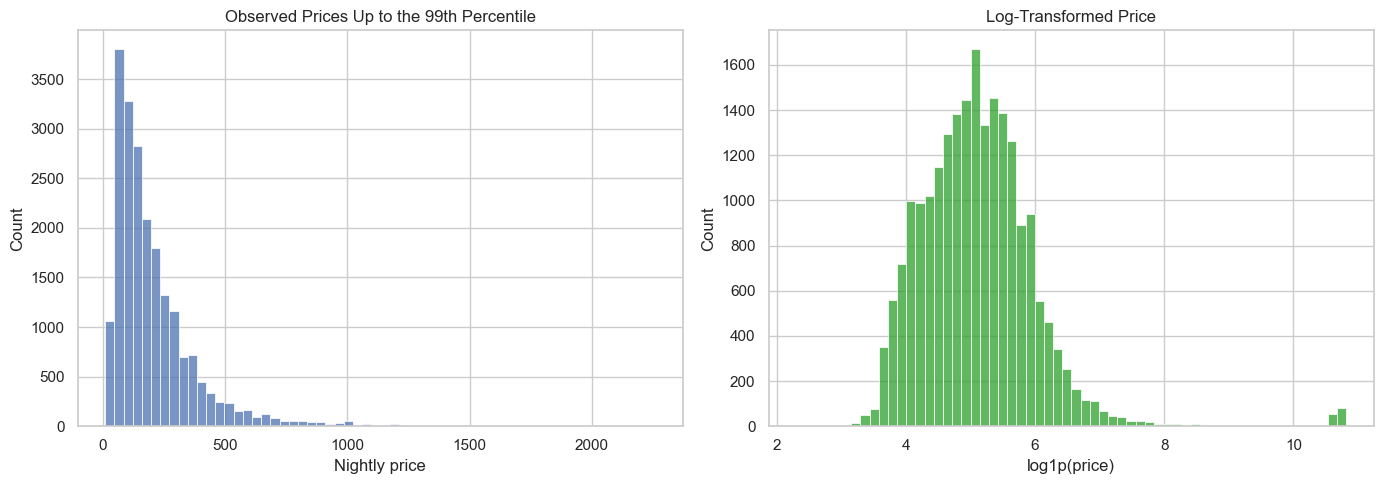

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(model_df.loc[model_df['price'].le(price_outlier_threshold), 'price'], bins=60, ax=axes[0])
axes[0].set_title('Observed Prices Up to the 99th Percentile')
axes[0].set_xlabel('Nightly price')

sns.histplot(model_df['log_price'], bins=60, ax=axes[1], color='tab:green')
axes[1].set_title('Log-Transformed Price')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()


In [15]:
high_price_examples = (
    model_df.sort_values('price', ascending=False)
    [['id', 'price', 'room_type', 'neighbourhood', 'neighbourhood_group', 'minimum_nights', 'availability_365', 'number_of_reviews']]
    .head(15)
)

high_price_examples


,id,price,room_type,neighbourhood,neighbourhood_group,minimum_nights,availability_365,number_of_reviews
24861,836109742135678312,"50,138.000",Hotel room,Hell's Kitchen,Manhattan,1.000,333,3
24865,836120834301143556,"50,092.000",Hotel room,Hell's Kitchen,Manhattan,1.000,336,9
35154,1445612474570459567,"50,025.000",Hotel room,Hell's Kitchen,Manhattan,1.000,188,0
35153,1445612470358206846,"50,025.000",Hotel room,Hell's Kitchen,Manhattan,1.000,188,0
35182,1445696411392807849,"50,000.000",Hotel room,Hell's Kitchen,Manhattan,1.000,347,0
35163,1445657883269221895,"50,000.000",Hotel room,Midtown,Manhattan,1.000,305,1
35178,1445696399294548212,"50,000.000",Hotel room,Hell's Kitchen,Manhattan,1.000,343,0
35180,1445696405031341358,"50,000.000",Hotel room,Hell's Kitchen,Manhattan,1.000,339,0
35181,1445696410573867233,"50,000.000",Hotel room,Hell's Kitchen,Manhattan,1.000,342,0
35183,1445696411752658886,"50,000.000",Hotel room,Hell's Kitchen,Manhattan,1.000,339,0


### Price by Listing Segment

Room type, borough, and neighborhood are core business drivers for a fair market price. These summaries also show which groups have enough observed labels to support modeling.


In [16]:
segment_summary = (
    model_df
    .groupby(['neighbourhood_group', 'room_type'], observed=True)
    .agg(
        listings=('id', 'count'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        p25_price=('price', lambda s: s.quantile(0.25)),
        p75_price=('price', lambda s: s.quantile(0.75)),
        p95_price=('price', lambda s: s.quantile(0.95)),
    )
    .reset_index()
    .sort_values(['neighbourhood_group', 'median_price'], ascending=[True, False])
)

segment_summary


,neighbourhood_group,room_type,listings,median_price,mean_price,p25_price,p75_price,p95_price
0,Bronx,Entire home/apt,330,134.000,172.803,99.000,193.250,364.550
1,Bronx,Private room,488,70.000,106.072,53.000,99.000,175.000
3,Brooklyn,Hotel room,19,"40,000.000","25,460.684",699.500,"40,000.000","40,000.000"
2,Brooklyn,Entire home/apt,3660,188.000,243.985,134.000,275.000,550.050
4,Brooklyn,Private room,3539,80.000,111.392,55.000,131.000,266.200
5,Brooklyn,Shared room,95,56.000,128.653,35.500,177.000,293.700
7,Manhattan,Hotel room,124,"40,000.000","37,196.403","40,000.000","50,000.000","50,000.000"
6,Manhattan,Entire home/apt,6946,250.000,350.261,165.000,364.000,780.750
8,Manhattan,Private room,2432,117.000,362.963,72.000,248.000,674.450
9,Manhattan,Shared room,56,37.500,186.054,36.000,115.500,701.250


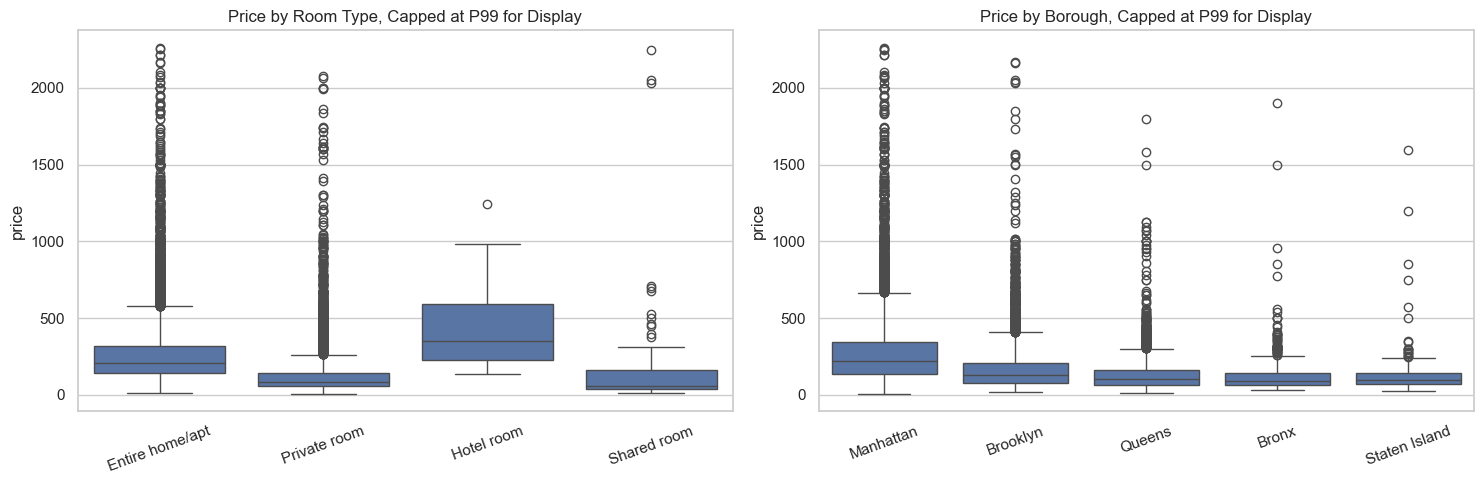

In [17]:
plot_df = model_df[model_df['price'].le(price_outlier_threshold)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=plot_df, x='room_type', y='price', ax=axes[0])
axes[0].set_title('Price by Room Type, Capped at P99 for Display')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=plot_df, x='neighbourhood_group', y='price', ax=axes[1])
axes[1].set_title('Price by Borough, Capped at P99 for Display')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()


In [18]:
neighbourhood_price_summary = (
    model_df
    .groupby(['neighbourhood_group', 'neighbourhood'], observed=True)
    .agg(
        listings=('id', 'count'),
        median_price=('price', 'median'),
        p75_price=('price', lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

min_neighbourhood_labels = 30
sparse_neighbourhoods = neighbourhood_price_summary[neighbourhood_price_summary['listings'].lt(min_neighbourhood_labels)]

neighbourhood_price_summary.sort_values(['median_price', 'listings'], ascending=[False, False]).head(20)


,neighbourhood_group,neighbourhood,listings,median_price,p75_price
11,Bronx,Country Club,1,"1,499.000","1,499.000"
35,Bronx,Riverdale,2,"1,038.000","1,469.000"
192,Staten Island,Fort Wadsworth,1,750.000,750.000
117,Manhattan,NoHo,22,485.000,803.500
120,Manhattan,SoHo,107,375.000,591.500
122,Manhattan,Theater District,221,373.000,502.000
123,Manhattan,Tribeca,91,366.000,546.000
103,Manhattan,Financial District,384,349.000,518.250
68,Brooklyn,DUMBO,16,337.500,409.000
104,Manhattan,Flatiron District,48,331.500,422.500


In [19]:
sparse_neighbourhood_summary = pd.Series({
    'min_labels_required': min_neighbourhood_labels,
    'sparse_neighbourhoods': len(sparse_neighbourhoods),
    'training_rows_in_sparse_neighbourhoods': int(sparse_neighbourhoods['listings'].sum()),
    'pct_training_rows_sparse': sparse_neighbourhoods['listings'].sum() / len(model_df) * 100,
})

sparse_neighbourhood_summary.to_frame('value')


,value
min_labels_required,30.000
sparse_neighbourhoods,120.000
training_rows_in_sparse_neighbourhoods,"1,261.000"
pct_training_rows_sparse,5.888


### Missing-Price Candidate Bias

Because many listings have no observed price, compare labeled training rows with missing-price candidates. If the missing-price group has a different room-type or borough mix, model predictions for those rows should be interpreted with that coverage limitation.


In [20]:
def distribution_compare(column):
    train_dist = model_df[column].value_counts(normalize=True).rename('observed_price_train_pct') * 100
    candidate_dist = pricing_candidates[column].value_counts(normalize=True).rename('missing_price_candidate_pct') * 100
    return (
        pd.concat([train_dist, candidate_dist], axis=1)
        .fillna(0)
        .assign(pct_point_gap=lambda x: x['missing_price_candidate_pct'] - x['observed_price_train_pct'])
        .sort_values('pct_point_gap', ascending=False)
    )

room_type_missing_bias = distribution_compare('room_type')
borough_missing_bias = distribution_compare('neighbourhood_group')

room_type_missing_bias, borough_missing_bias


(                 observed_price_train_pct  missing_price_candidate_pct  \
 room_type                                                                
 Private room                       40.177                       50.549   
 Hotel room                          0.799                        1.176   
 Shared room                         0.929                        0.690   
 Entire home/apt                    58.095                       47.584   
 
                  pct_point_gap  
 room_type                       
 Private room            10.372  
 Hotel room               0.378  
 Shared room             -0.239  
 Entire home/apt        -10.511  ,
                      observed_price_train_pct  missing_price_candidate_pct  \
 neighbourhood_group                                                          
 Brooklyn                               34.149                       38.605   
 Manhattan                              44.632                       45.982   
 Staten Island             

### Numeric Feature Relationships

The correlation table uses `log_price` because it better reflects proportional price differences. It is an EDA guide, not a final feature-selection rule.


In [21]:
numeric_feature_cols = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm',
    'reviews_last_30d', 'reviews_last_90d', 'reviews_last_365d', 'days_since_last_review',
    'is_licensed', 'no_reviews', 'days_since_last_review_missing',
]

correlation_summary = (
    model_df[numeric_feature_cols + ['log_price']]
    .corr(numeric_only=True)['log_price']
    .drop('log_price')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame('corr_with_log_price')
)

correlation_summary


,corr_with_log_price
longitude,-0.284
is_licensed,0.276
calculated_host_listings_count,0.135
minimum_nights,-0.128
days_since_last_review_missing,0.108
days_since_last_review,0.108
no_reviews,0.106
latitude,0.085
availability_365,0.069
reviews_last_90d,0.068


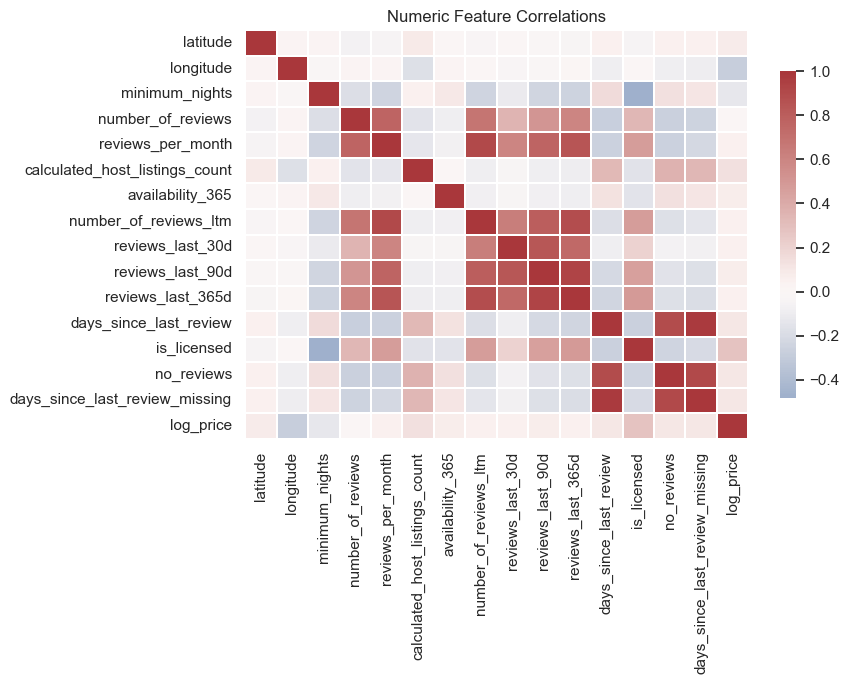

In [22]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    model_df[numeric_feature_cols + ['log_price']].corr(numeric_only=True),
    cmap='vlag',
    center=0,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8},
)
plt.title('Numeric Feature Correlations')
plt.tight_layout()


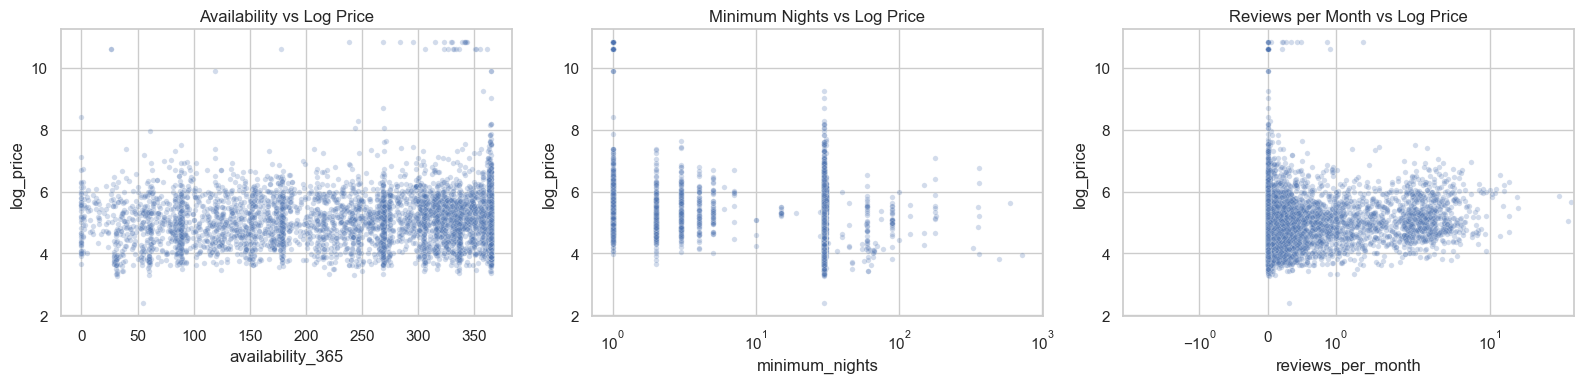

In [23]:
sample_df = model_df.sample(min(5000, len(model_df)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(data=sample_df, x='availability_365', y='log_price', alpha=0.25, ax=axes[0], s=15)
axes[0].set_title('Availability vs Log Price')

sns.scatterplot(data=sample_df, x='minimum_nights', y='log_price', alpha=0.25, ax=axes[1], s=15)
axes[1].set_xscale('log')
axes[1].set_title('Minimum Nights vs Log Price')

sns.scatterplot(data=sample_df, x='reviews_per_month', y='log_price', alpha=0.25, ax=axes[2], s=15)
axes[2].set_xscale('symlog')
axes[2].set_title('Reviews per Month vs Log Price')

plt.tight_layout()


### Geographic Pattern Check

Latitude and longitude often capture neighborhood-level price gradients. This plot is sampled and capped for readability.


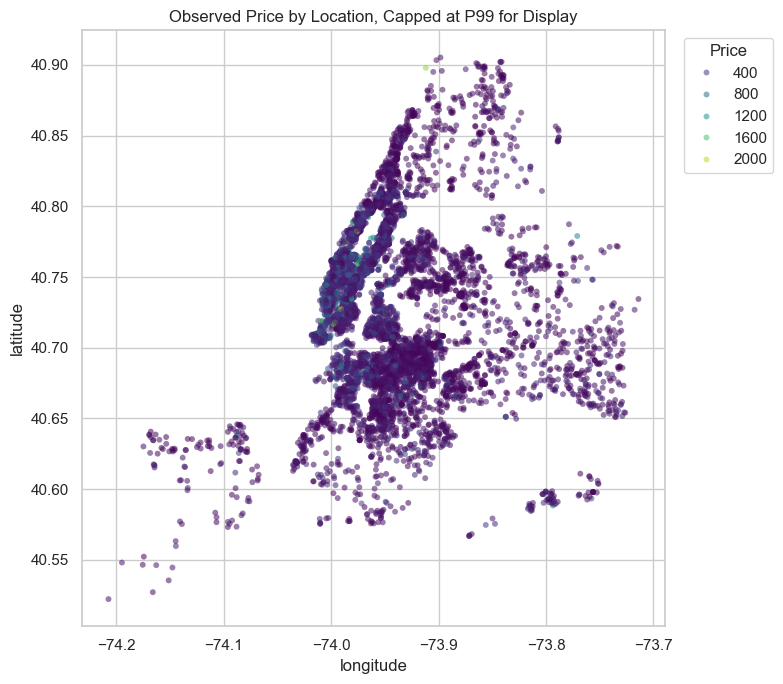

In [24]:
geo_plot_df = model_df[model_df['price'].le(price_outlier_threshold)].sample(
    min(8000, len(model_df)), random_state=42
)

plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=geo_plot_df,
    x='longitude',
    y='latitude',
    hue='price',
    palette='viridis',
    alpha=0.55,
    s=18,
    linewidth=0,
)
plt.title('Observed Price by Location, Capped at P99 for Display')
plt.legend(title='Price', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


## Final Modeling Dataset

These cleaning steps are applied after EDA: remove the top 1% observed-price outliers from training, group sparse neighborhoods into `Other`, and cap highly skewed numeric predictors. The original cleaned dataset remains available as `df_clean`.


In [25]:
model_ready_df = model_df[model_df['price'].le(price_outlier_threshold)].copy()

frequent_neighbourhoods = (
    model_ready_df['neighbourhood']
    .value_counts()
    .loc[lambda s: s.ge(min_neighbourhood_labels)]
    .index
)
model_ready_df['neighbourhood_model'] = np.where(
    model_ready_df['neighbourhood'].isin(frequent_neighbourhoods),
    model_ready_df['neighbourhood'],
    'Other',
)

skewed_feature_cols = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'number_of_reviews_ltm',
    'reviews_last_30d', 'reviews_last_90d', 'reviews_last_365d',
    'days_since_last_review',
]

feature_cap_values = model_ready_df[skewed_feature_cols].quantile(0.99)
for col in skewed_feature_cols:
    model_ready_df[f'{col}_capped'] = model_ready_df[col].clip(upper=feature_cap_values[col])
    model_ready_df[f'log1p_{col}_capped'] = np.log1p(model_ready_df[f'{col}_capped'])

candidate_ready_df = pricing_candidates.copy()
candidate_ready_df['neighbourhood_model'] = np.where(
    candidate_ready_df['neighbourhood'].isin(frequent_neighbourhoods),
    candidate_ready_df['neighbourhood'],
    'Other',
)
for col in skewed_feature_cols:
    candidate_ready_df[f'{col}_capped'] = candidate_ready_df[col].clip(upper=feature_cap_values[col])
    candidate_ready_df[f'log1p_{col}_capped'] = np.log1p(candidate_ready_df[f'{col}_capped'])

modeling_features = [
    'room_type', 'neighbourhood_group', 'neighbourhood_model', 'latitude', 'longitude',
    'availability_365', 'is_licensed', 'no_reviews', 'days_since_last_review_missing',
    *[f'log1p_{col}_capped' for col in skewed_feature_cols],
]

target_col = 'log_price'

model_ready_summary = pd.Series({
    'model_ready_rows': len(model_ready_df),
    'rows_removed_as_top_1pct_price_outliers': len(model_df) - len(model_ready_df),
    'modeling_features': len(modeling_features),
    'neighbourhood_levels_after_grouping': model_ready_df['neighbourhood_model'].nunique(),
    'candidate_rows_ready_for_scoring': len(candidate_ready_df),
    'remaining_missing_model_features': int(model_ready_df[modeling_features].isna().sum().sum()),
    'remaining_missing_target': int(model_ready_df[target_col].isna().sum()),
})

model_ready_summary.to_frame('value')


,value
model_ready_rows,21200
rows_removed_as_top_1pct_price_outliers,215
modeling_features,18
neighbourhood_levels_after_grouping,103
candidate_rows_ready_for_scoring,16661
remaining_missing_model_features,0
remaining_missing_target,0


In [26]:
model_ready_df[modeling_features + ['price', target_col]].head()


,room_type,neighbourhood_group,neighbourhood_model,latitude,longitude,availability_365,is_licensed,no_reviews,days_since_last_review_missing,log1p_minimum_nights_capped,log1p_number_of_reviews_capped,log1p_reviews_per_month_capped,log1p_calculated_host_listings_count_capped,log1p_number_of_reviews_ltm_capped,log1p_reviews_last_30d_capped,log1p_reviews_last_90d_capped,log1p_reviews_last_365d_capped,log1p_days_since_last_review_capped,price,log_price
1,Entire home/apt,Manhattan,Midtown,40.754,-73.986,319,0,0,0,3.434,3.871,0.215,1.386,0.000,0.000,0.000,0.000,7.186,240.000,5.485
2,Entire home/apt,Brooklyn,Williamsburg,40.709,-73.953,270,0,0,0,3.434,5.288,0.681,0.693,1.609,0.000,0.000,1.609,4.331,139.000,4.942
3,Private room,Manhattan,East Harlem,40.801,-73.943,83,0,0,0,3.434,1.099,0.049,1.099,0.693,0.000,0.000,0.693,4.762,59.000,4.094
4,Private room,Manhattan,East Harlem,40.788,-73.948,302,0,0,0,3.434,5.529,0.822,0.693,1.609,0.000,1.099,1.609,3.045,73.000,4.304
6,Private room,Brooklyn,Fort Greene,40.692,-73.974,0,1,0,0,1.099,5.900,1.158,1.099,3.526,0.000,0.000,3.296,4.875,216.000,5.380


## Modeling Fair Nightly Price

The model should answer the business question directly: estimate a fair nightly price from listing and review characteristics, then compare actual listed prices against that estimate. The median baseline shows what happens if we ignore listing details, while the tree models test whether nonlinear location, room, availability, and review patterns improve the fair-price estimate.

In [27]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

# Split the model-ready data into training and validation sets.
categorical_features = ['room_type', 'neighbourhood_group', 'neighbourhood_model']
numeric_features = [col for col in modeling_features if col not in categorical_features]

X = model_ready_df[modeling_features]
y = model_ready_df[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

# Build preprocessing for linear and tree models.
linear_preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('numeric', StandardScaler(), numeric_features),
])

tree_preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('numeric', 'passthrough', numeric_features),
])

# Define the baseline and candidate tree models.
models = {
    'Median baseline': DummyRegressor(strategy='median'),
    'Ridge baseline': Pipeline([
        ('preprocess', linear_preprocessor),
        ('model', Ridge(alpha=10.0)),
    ]),
    'Random forest': Pipeline([
        ('preprocess', tree_preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    'XGBoost': Pipeline([
        ('preprocess', tree_preprocessor),
        ('model', XGBRegressor(
            objective='reg:squarederror',
            eval_metric='rmse',
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.90,
            colsample_bytree=0.85,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}


In [28]:
# Train each model and compare validation performance in business units.
model_scores = []
trained_models = {}
actual_price = np.expm1(y_valid)

for name, model in models.items():
    model.fit(X_train, y_train)
    predicted_log_price = model.predict(X_valid)
    predicted_price = np.expm1(predicted_log_price).clip(min=0)

    trained_models[name] = model
    model_scores.append({
        'model': name,
        'mae_dollars': mean_absolute_error(actual_price, predicted_price),
        'rmse_dollars': np.sqrt(mean_squared_error(actual_price, predicted_price)),
        'r2_log_price': r2_score(y_valid, predicted_log_price),
        'median_abs_pct_error': np.median(np.abs(actual_price - predicted_price) / actual_price) * 100,
    })

model_results = (
    pd.DataFrame(model_scores)
    .sort_values('mae_dollars')
    .reset_index(drop=True)
)

model_results


,model,mae_dollars,rmse_dollars,r2_log_price,median_abs_pct_error
0,Random forest,68.675,146.605,0.713,21.624
1,XGBoost,73.103,153.517,0.687,25.087
2,Ridge baseline,85.605,167.096,0.589,30.837
3,Median baseline,120.526,208.656,-0.001,49.333


In [29]:
# Refit the best model on all observed-price training rows.
best_model_name = model_results.loc[0, 'model']
best_model = clone(trained_models[best_model_name])
best_model.fit(X, y)

# Estimate fair prices for observed listings and flag pricing position.
model_ready_df['fair_price_estimate'] = np.expm1(best_model.predict(X)).clip(min=0)
model_ready_df['price_vs_fair_pct'] = (
    model_ready_df['price'] - model_ready_df['fair_price_estimate']
) / model_ready_df['fair_price_estimate']

pricing_threshold = 0.15
model_ready_df['price_position'] = np.select(
    [
        model_ready_df['price_vs_fair_pct'].ge(pricing_threshold),
        model_ready_df['price_vs_fair_pct'].le(-pricing_threshold),
    ],
    ['above_market', 'below_market'],
    default='near_market',
)

# Score missing-price listings as fair-price candidates.
candidate_ready_df['predicted_fair_price'] = np.expm1(
    best_model.predict(candidate_ready_df[modeling_features])
).clip(min=0)

business_model_summary = pd.Series({
    'selected_model': best_model_name,
    'validation_mae_dollars': model_results.loc[0, 'mae_dollars'],
    'validation_rmse_dollars': model_results.loc[0, 'rmse_dollars'],
    'validation_r2_log_price': model_results.loc[0, 'r2_log_price'],
    'pricing_threshold_pct': pricing_threshold * 100,
    'observed_listings_scored': len(model_ready_df),
    'missing_price_candidates_scored': len(candidate_ready_df),
})

business_model_summary.to_frame('value')


,value
selected_model,Random forest
validation_mae_dollars,68.675
validation_rmse_dollars,146.605
validation_r2_log_price,0.713
pricing_threshold_pct,15.000
observed_listings_scored,21200
missing_price_candidates_scored,16661


In [30]:
# Summarize which observed listings look above, near, or below fair market.
pricing_position_summary = (
    model_ready_df['price_position']
    .value_counts()
    .rename_axis('price_position')
    .to_frame('listings')
)
pricing_position_summary['pct_of_observed_listings'] = (
    pricing_position_summary['listings'] / len(model_ready_df) * 100
).round(2)

pricing_position_summary


,listings,pct_of_observed_listings
price_position,,
near_market,11289,53.250
below_market,5197,24.510
above_market,4714,22.240


In [31]:
# Show the highest predicted fair prices among missing-price candidates.
candidate_price_predictions = candidate_ready_df[
    ['id', 'room_type', 'neighbourhood_group', 'neighbourhood', 'predicted_fair_price']
].sort_values('predicted_fair_price', ascending=False)

candidate_price_predictions.head(10)


,id,room_type,neighbourhood_group,neighbourhood,predicted_fair_price
27063,960814393147089142,Private room,Manhattan,Midtown,"1,096.454"
23022,744906774156280600,Entire home/apt,Manhattan,Harlem,"1,071.199"
13686,37729855,Private room,Manhattan,Midtown,879.287
36947,1537619659563740944,Private room,Manhattan,Midtown,865.251
36921,1536832095193482598,Private room,Manhattan,Midtown,865.251
36922,1536832424053231575,Private room,Manhattan,Midtown,865.251
36923,1536832430277709991,Private room,Manhattan,Midtown,865.251
36924,1536832592286896296,Private room,Manhattan,Midtown,865.251
14005,38956813,Hotel room,Manhattan,Midtown,854.072
11942,31001555,Private room,Manhattan,Midtown,846.819


### Some Initial Summary

- The median model is the no-feature baseline; any useful fair-price model should beat that dollar error.
- The Ridge baseline tests whether simple additive feature effects are enough before relying on tree models.
- Random Forest and XGBoost capture nonlinear price patterns across room type, location, availability, and reviews.
- The selected model is the lowest validation-MAE model and creates `fair_price_estimate`, `price_vs_fair_pct`, and `price_position`.
- Missing-price listings are scored in `candidate_ready_df` with `predicted_fair_price`, so they can be priced from the learned market pattern.


### Further evaluation will be made